# Analysis of rf playback experiment

## setup

In [1]:
%load_ext autoreload
%autoreload 2

In [56]:
import os
import datajoint as dj
from warnings import simplefilter

In [57]:
simplefilter(action='ignore', category=FutureWarning)

In [3]:
username = !whoami
username = username[0]
username

'ssuhai'

In [4]:
home_directory = os.path.expanduser("~")
home_directory

'/gpfs01/euler/User/ssuhai'

In [5]:
# Path to djimaging
path_to_djimaging = f'{home_directory}/GitRepos/'

# Clone djimaging if you haven't downloaded it yet
# assert os.isdir(path_to_djimaging), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging} && git clone git@github.com:eulerlab/djimaging.git

# Install djimaging if not done yet
# assert os.isdir(os.path.join(path_to_djimaging, 'djimaging')), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging}/djimaging/ && sudo pip install -e .

In [6]:
# Set config file
config_file = f'{home_directory}/datajoint/dj_{username}_conf.json'
assert os.path.isfile(config_file), f'Set the path to your config file: {config_file}'

In [7]:
# Define a schema name or use the default name for your personal test schema
# It should start with ageuler and have some meaningful name after that
schema_name = f"ageuler_{username}_closed_loop_rf_est"

In [8]:
# Do you want to use the RGC classifier?
# If so, make sure to add the respective tables into your schema.
use_rgc_classifier = True

if use_rgc_classifier:  # Define any existing outputfolder for the classifier to be saved
    output_folder = f'{home_directory}/datajoint/rgc_classifier'
    assert os.path.isdir(output_folder), f'Set path to output directory: {output_folder}'

In [9]:
# Load configuration for user
dj.config.load(config_file)
dj.config['schema_name'] = schema_name

if use_rgc_classifier:
    from djimaging.tables.classifier.rgc_classifier import prepare_dj_config_rgc_classifier
    prepare_dj_config_rgc_classifier(output_folder)

print("schema_name:", dj.config['schema_name'])
dj.conn()

[2025-08-13 16:06:27,110][INFO]: Connecting ssuhai@172.25.240.200:3306
[2025-08-13 16:06:27,168][INFO]: Connected ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_closed_loop_rf_est


DataJoint connection (connected) ssuhai@172.25.240.200:3306

In [10]:
from djimaging.schemas.tutorial_schema import *

In [14]:
from djimaging.utils.dj_utils import activate_schema

activate_schema(schema=schema, create_schema=True, create_tables=True)
schema

[2025-08-13 16:18:42,983][WARNING]: MySQL server has gone away. Reconnecting to the server.


Schema `ageuler_ssuhai_closed_loop_rf_est`

In [44]:
userinfo = {
    'experimenter': 'FloJaneSamuel', # Replace this if you want to use your own data
    'data_dir': '/gpfs01/euler/data/Data/Suhai/thesis/rf_test/', # Replace this if you want to use your own data
    'animal_loc': 1,
    'region_loc': 2,
    'field_loc': 3,
    'stimulus_loc': 4,
    'cond1_loc': 5,

}

assert os.path.isdir(userinfo['data_dir'])

In [45]:
UserInfo().upload_user(userinfo)


In [46]:
RawDataParams().add_default()


In [47]:
RawDataParams().update1(dict(
            experimenter='FloJaneSamuel',
            raw_id=int(1),
            from_raw_data=int(1),
            igor_roi_masks='no',
            ))

In [48]:
RawDataParams()

experimenter name of the experimenter,raw_id unique param set id,from_raw_data Load raw smp data (1) or h5 data (0),compute_from_stack Compute traces from stack. Otherwise try to import Igor traces.,include_artifacts automatically exclude all ROIs with artifacts?,trace_precision Compute traces with either line precision or pixel precision?,trigger_precision Compute triggers with either line precision or pixel precision?,"igor_roi_masks Either load or ignore existing ROI masks, e.g. from Igor"
FloJaneSamuel,1,1,1,0,line,line,no


In [ ]:
Experiment().rescan_filesystem(verboselvl=2)
Field().rescan_filesystem(verboselvl=2)




Scanning for experimenter: FloJaneSamuel
	header_path: /gpfs01/euler/data/Data/Suhai/thesis/rf_test/20250813/1
		header_name: 20250813_left.ini
		Adding: {'experimenter': 'FloJaneSamuel', 'date': datetime.datetime(2025, 8, 13, 0, 0), 'exp_num': 1}
Found 4 files in 1 fields for key={'experimenter': 'FloJaneSamuel', 'date': datetime.date(2025, 8, 13), 'exp_num': 1, 'raw_id': 1}
	Adding field: `{'field': 'GCL1', 'region': 'RR', 'cond1': '1', 'experimenter': 'FloJaneSamuel', 'date': datetime.date(2025, 8, 13), 'exp_num': 1, 'raw_id': 1}`


/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/field.py:128: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  file_info_df['cond1'].fillna('control', inplace=True)
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/field.py:134: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

In [145]:
# To compute receptive fields, the noise stimulus trace must be loaded and set!
import h5py

with h5py.File("/gpfs01/euler/data/Resources/Stimulus/noise.h5", "r") as f:
    noise_stimulus = f['stimulusarray'][:].T.astype(int)

noise_stimulus = noise_stimulus*2-1


Stimulus().add_nostim(skip_duplicates=True)
Stimulus().add_chirp(spatialextent=1000, stim_name='gChirp', alias="chirp_gchirp_globalchirp", skip_duplicates=True)
Stimulus().add_chirp(spatialextent=300, stim_name='lChirp', alias="lchirp_localchirp", skip_duplicates=True)
Stimulus().add_noise(stim_name='densenoise', pix_n_x=20, pix_n_y=15, pix_scale_x_um=40, pix_scale_y_um=40,framerate=5, stim_trace=noise_stimulus, skip_duplicates=True)
Stimulus().add_movingbar(skip_duplicates=True)

/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:195: UserWarning: Stimulus offset not set. Assuming 0 offset. This is incorrect for the standard dense noise stimulus.
  warnings.warn(
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:203: UserWarning: Stimulus offset not set. Assuming 0 offset. This is incorrect for the standard dense noise stimulus.
  warnings.warn(
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:112: UserWarning: Values for ['bardx', 'bardy', 'velumsec', 'tmovedurs'] in `stim_dict` for stimulus `movingbar` are None. This may cause problems downstream.
  warnings.warn(f'Values for {missing_info} in `stim_dict` for stimulus `{stim_name}` are None. '
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:39: UserWarning: Number of triggers in trial_info=8 must match ntrigger_rep=1.
  warnings.warn(msg)


In [146]:
log_path = "/gpfs01/euler/data/Data/Suhai/thesis/rf_test_metadata/log.txt"
stim_path = "/gpfs01/euler/data/Data/Suhai/thesis/rf_test_metadata/rf_test_stimulus.avi"
presentation_location = "/gpfs01/euler/data/Data/Suhai/thesis/rf_test_metadata/rf_test_stimulus_metadata.txt"
with open(log_path, 'r') as f:
    lines = f.readlines()
print(lines)

# load presentation location file 
with open(presentation_location, 'r') as f:
    presentation_lines = f.readlines()
presentation_lines = [line.strip() for line in presentation_lines if line.strip()]
location_list = [(float(pres.split(",")[0]),float(pres.split(",")[1])) for pres in presentation_lines[0].split(':')]
print(presentation_lines)
print(location_list)

['Log started on 2025-08-13\n', '2025-08-13 15:27:14 - Created RF AVI for ROI IDs: [78, 71, 87, 86, 80, 66, 62, 33, 35, 4, 21, 11, 3, 42, 47]\n']
['60.0,0.0:20.0,-40.0:100.0,40.0:60.0,0.0:20.0,0.0:20.0,0.0:-20.0,40.0:60.0,40.0:-20.0,0.0:-20.0,0.0:20.0,-40.0:-20.0,40.0:-20.0,0.0:-60.0,40.0:-60.0,0.0']
[(60.0, 0.0), (20.0, -40.0), (100.0, 40.0), (60.0, 0.0), (20.0, 0.0), (20.0, 0.0), (-20.0, 40.0), (60.0, 40.0), (-20.0, 0.0), (-20.0, 0.0), (20.0, -40.0), (-20.0, 40.0), (-20.0, 0.0), (-60.0, 40.0), (-60.0, 0.0)]


In [52]:
roi_ids = [78, 71, 87, 86, 80, 66, 62, 33, 35, 4, 21, 11, 3, 42, 47]

In [148]:
# Add rf test stimulus 
nr_triggers_per_roi = 2 * 2 # each roi has 2 stim and 2 tiggers per stim 
info_dict =     {
    "stim_name": "RF",
    "alias": "rf",
    "framerate": 60,
    "ntrigger_rep": nr_triggers_per_roi * len(roi_ids), # one for 50x50 one for 100x100
    "stim_path" : stim_path,
}

Stimulus().add_stimulus(
    **info_dict
)

# Stimulus().update1(info_dict)
Stimulus()

stim_name Unique string identifier,"alias Strings (_ seperator) to identify this stimulus, not case sensitive!",stim_family To group stimuli (e.g. gChirp and lChirp) for downstream processing,framerate framerate in Hz,isrepeated Is the stimulus repeated? Used for snippets,ntrigger_rep Number of triggers (per repetition),stim_path Path to hdf5 file containing numerical array and info about stim,commit_id Commit id corresponding to stimulus entry in GitHub repo,stim_hash QDSpy hash,"trial_info trial information, e.g. directions of moving bar",stim_trace array of stimulus if available,"stim_dict stimulus information dictionary, contains e.g. spatial extent",snippet_base_dt Time used for snippet baseline estimation
densenoise,dn_noise_dn40m_noise40m,noise,5.0,0,1500,,,,=BLOB=,=BLOB=,=BLOB=,nan
gChirp,chirp_gchirp_globalchirp,chirp,0.0166667,1,2,,,,=BLOB=,=BLOB=,=BLOB=,nan
lChirp,lchirp_localchirp,chirp,0.0166667,1,2,,,,=BLOB=,=BLOB=,=BLOB=,nan
movingbar,mb_mbar_bar_movingbar,movingbar,0.0166667,1,1,,,,=BLOB=,=BLOB=,=BLOB=,nan
nostim,nostim_none,,0.0,0,0,,,,=BLOB=,=BLOB=,=BLOB=,nan
RF,rf,,60.0,0,60,/gpfs01/euler/data/Data/Suhai/thesis/rf_test_metadata/rf_test_stimulus.avi,,,=BLOB=,=BLOB=,=BLOB=,nan


In [ ]:
Presentation().populate(processes=20, display_progress=True)

Presentation: 100%|██████████| 6/6 [00:09<00:00,  1.67s/it]


{'success_count': 6, 'error_list': []}

In [ ]:
# Presentation().delete()

[2025-08-13 17:02:11,975][INFO]: Deleting 4 rows from `ageuler_ssuhai_closed_loop_rf_est`.`__presentation__scan_info`


[2025-08-13 17:02:12,034][INFO]: Deleting 12 rows from `ageuler_ssuhai_closed_loop_rf_est`.`__presentation__stack_averages`
[2025-08-13 17:02:12,067][INFO]: Deleting 4 rows from `ageuler_ssuhai_closed_loop_rf_est`.`__presentation`
[2025-08-13 17:02:16,087][WARNING]: Deletes cancelled


4

In [67]:
# load the online roi mask to compare
import pickle
mask_path = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_rfs/20250717/1/ROIs/M1_RR_GCL1_chirp_iter0_ROIs.pkl"
with open(mask_path, 'rb') as f:
    online_roi_mask = pickle.load(f)


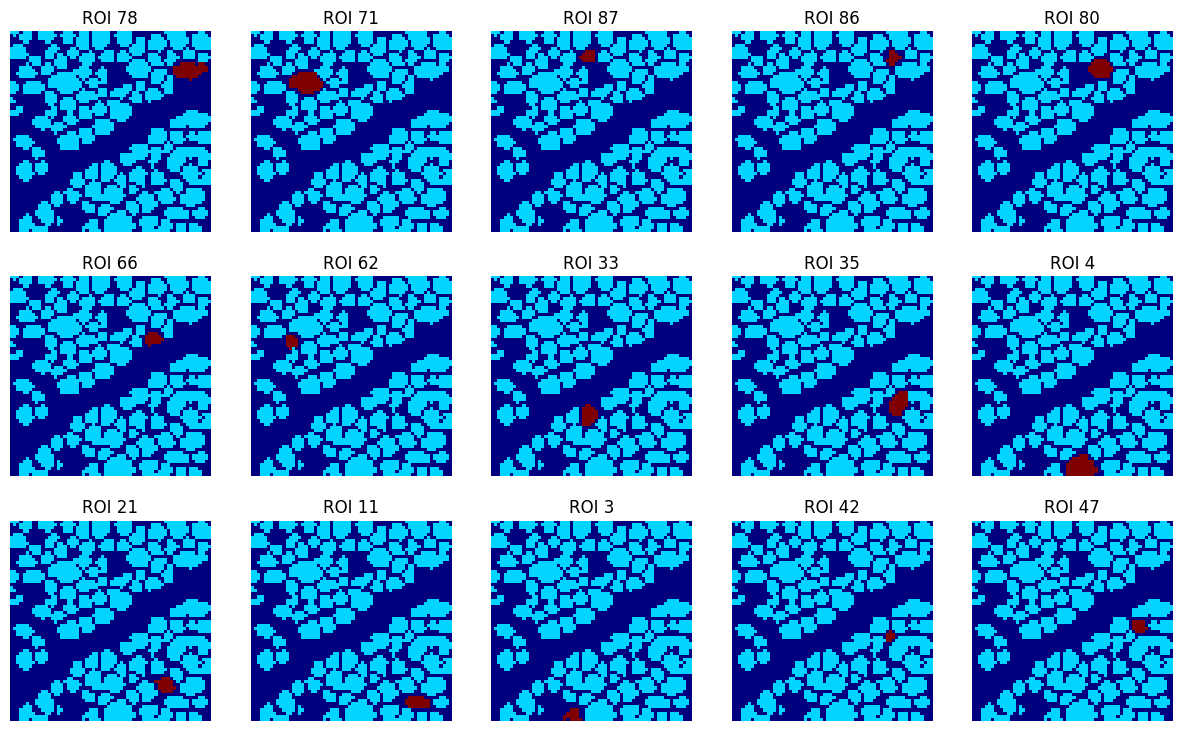

In [80]:
import matplotlib.pyplot as plt
import numpy as np
n_rois = len(roi_ids)

# plot the rois in roi_ids
fig,ax = plt.subplots(3,5, figsize=(15, 9))
for i, roi_id in enumerate(roi_ids):
    highlighted_roi = (online_roi_mask == roi_id) *100 + (online_roi_mask >=1) * 50
    ax[i//5, i%5].imshow(np.rot90(highlighted_roi, k=1), cmap="jet")
    ax[i//5, i%5].set_title(f"ROI {roi_id}")
    ax[i//5, i%5].axis('off')

#plt.imshow(np.rot90(online_roi_mask,k=1),cmap= "jet")

In [ ]:
# If you have save some of you AutoROIs ROI masks you can load them here.
RoiMask().rescan_filesystem(verboselvl=2)
missing_fields = RoiMask().list_missing_field()
field_key = missing_fields.pop()  # Pick one field

# Load ROI canvas, draw the ROI mask, clean it if you want, shift if you want.
# You can then save it to a file to be able to load it again later.
roi_canvas = RoiMask().draw_roi_mask(field_key=field_key, canvas_width=30)
roi_canvas.start_gui()

No ROI masks found for field: {'experimenter': 'FloJaneSamuel', 'date': datetime.date(2025, 8, 13), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL1', 'region': 'RR', 'cond1': '1'}
Load model weights for cpu from checkpoint /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/dropout_and_aug_regul.ckpt using config /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/sd_images.yaml


Returned InteractiveRoiCanvas object. To start GUI, call <enter_object_name>.start_gui().


In [151]:
# Load the just saved ROI mask
RoiMask().rescan_filesystem(verboselvl=2)

Adding 4 ROI masks for field: {'experimenter': 'FloJaneSamuel', 'date': datetime.date(2025, 8, 13), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL1', 'region': 'RR', 'cond1': '1'}


[]

In [152]:
Roi().populate(processes=20, display_progress=True)
Roi()

Roi: 100%|██████████| 1/1 [00:00<00:00,  4.17it/s]


experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),roi_id integer id of each ROI,roi_size number of pixels in ROI,roi_size_um2 size of ROI in micrometers squared,"roi_dia_um diameter of ROI in micrometers, if it was a circle",artifact_flag flag if roi contains light artifact (1) or not (0)
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,1,22,89.014,10.6459,0
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,2,9,36.4148,6.80917,0
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,3,20,80.9218,10.1505,0
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,4,54,218.489,16.679,0
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,5,26,105.198,11.5734,0
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,6,16,64.7375,9.07889,0
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,7,9,36.4148,6.80917,0
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,8,11,44.507,7.52782,0
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,9,23,93.0601,10.8852,0
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,10,34,137.567,13.2346,0


In [153]:
Traces().populate(processes=20, display_progress=True)


Processes:   0%|          | 0/4 [00:00<?, ?it/s]

Processes: 100%|██████████| 4/4 [00:03<00:00,  1.11it/s]


{'success_count': 4, 'error_list': []}

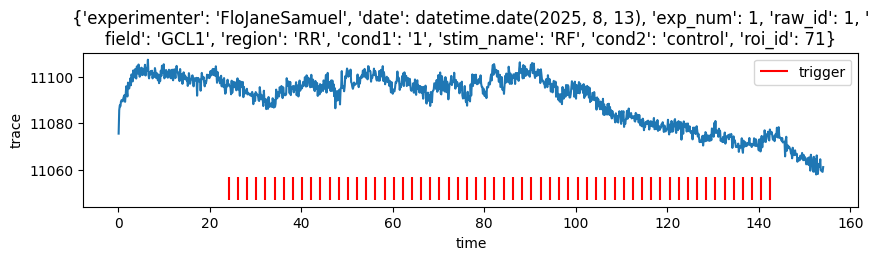

In [156]:
(Traces() & dict(stim_name="RF")).plot1()

In [157]:
PreprocessParams().add_default(fs_resample = 60,skip_duplicates=True)
PreprocessParams()

stim_name Unique string identifier,preprocess_id unique param set id,window_length window length for SavGol filter in seconds,poly_order order of polynomial for savgol filter,non_negative Clip negative values of trace,subtract_baseline Subtract baseline,"standardize standardize (1: with sd of baseline, 2: sd of trace, 0: nothing)","f_cutoff Cutoff frequency for low pass filter, only applied when > 0.","fs_resample Resampling frequency, only applied when > 0."
densenoise,1,60,3,0,1,1,0.0,60.0
gChirp,1,60,3,0,1,1,0.0,60.0
lChirp,1,60,3,0,1,1,0.0,60.0
movingbar,1,60,3,0,1,1,0.0,60.0
nostim,1,60,3,0,1,1,0.0,60.0
RF,1,60,3,0,1,1,0.0,60.0


In [158]:
PreprocessTraces().populate(processes=20, display_progress=True)


Processes: 100%|██████████| 407/407 [00:02<00:00, 192.73it/s]


{'success_count': 407, 'error_list': []}

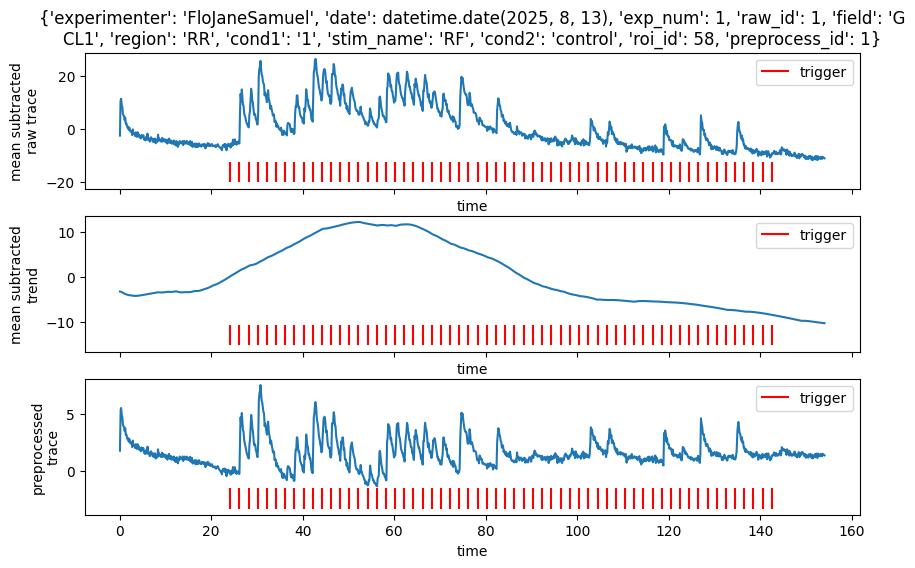

In [ ]:

(PreprocessTraces() & {"roi_is": roi_ids[6],"stim_name":"RF"}).plot1()

## analysis

In [160]:
# first look at the quailty of the rois
Snippets().populate(processes=20, display_progress=True)
Averages().populate(processes=20, display_progress=True)


ChirpQI().populate(display_progress=True, processes=20)
OsDsIndexes().populate(display_progress=True, processes=20)



Processes: 100%|██████████| 98/98 [00:18<00:00,  5.32it/s]


{'success_count': 98, 'error_list': []}

In [161]:
ChirpQI() & f"roi_id in {tuple(roi_ids)}"

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,gChirp,control,3,1,0.925796,0.2
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,gChirp,control,4,1,0.917397,0.2
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,gChirp,control,11,1,0.914233,0.2
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,gChirp,control,21,1,0.694958,0.2
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,gChirp,control,33,1,0.957151,0.2
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,gChirp,control,35,1,0.828487,0.2
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,gChirp,control,42,1,0.695392,0.2
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,gChirp,control,47,1,0.913384,0.2
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,gChirp,control,62,1,0.292917,0.2
FloJaneSamuel,2025-08-13,1,1,GCL1,RR,1,gChirp,control,66,1,0.878387,0.2


In [166]:
roi_ids

[3, 4, 11, 21, 33, 35, 42, 47, 62, 66, 71, 78, 80, 86, 87]

In [165]:
roi_ids.sort()

In [234]:
def fetch_pp_trace_triggers(restricted_pp_table):
     

    pp_trace_t0, pp_trace_dt, pp_trace, smoothed_trace = restricted_pp_table.fetch1(
        "pp_trace_t0", "pp_trace_dt", "pp_trace", "smoothed_trace")
    triggertimes = (restricted_pp_table.presentation_table() & {"stim_name":"RF"}).fetch1("triggertimes")

    pp_trace_times = np.arange(pp_trace.size) * pp_trace_dt + pp_trace_t0

    return pp_trace_times, pp_trace, triggertimes


def find_trggertime_for_roi(triggertimes,roi_ids,roi):
    """
    Finds the start and stop of the trigger time for a given ROI index.
    uses the fact that rois were presented successively in an ascending order.
    that the list was presented twice, and that each roi has TWO trigges,
    returns a list with two tupples with start stop in them.
    """
    trigger_duration = 2.0  #  seconds between triggers
    n_trigger_per_roi = 2  # each roi has two triggers, one for each presentation
    
    assert len(roi_ids) * trigger_duration * n_trigger_per_roi == len(triggertimes), \
        "The number of triggers should be twice the number of ROIs but got {} triggers for {} ROIs".format(len(triggertimes), len(roi_ids))
    

    assert np.max((np.abs(np.diff(triggertimes)- trigger_duration))) < 0.1, \
        f" max abs diff to expercted duration time {trigger_duration} vs {np.max((np.diff(triggertimes)- trigger_duration).abs())}"

    # get presentation index. rois are shown in ascending order, so we sort the roi_ids and see where roi is
    roi_ids.sort()
    roi_idx = roi_ids.index(roi)

    first_trigger_idx = n_trigger_per_roi * roi_idx

    # First presentation: ROI at index idx corresponds to trigger at index idx
    first_trigger_start = triggertimes[first_trigger_idx]
    first_trigger_stop = first_trigger_start + trigger_duration *n_trigger_per_roi
    
    # Second presentation: ROI at index idx corresponds to trigger at index (n_rois + presentation_index)
    n_rois = len(roi_ids)
    second_trigger_idx = n_rois * n_trigger_per_roi + first_trigger_idx
    second_trigger_start = triggertimes[second_trigger_idx]
    second_trigger_stop = second_trigger_start + trigger_duration * n_trigger_per_roi
    
    return [(first_trigger_start, first_trigger_stop), 
            (second_trigger_start, second_trigger_stop)]

def plot_roi_traces_highlighted(pp_trace_times, 
                                pp_trace, 
                                triggertimes, 
                                roi_ids, 
                                roi, 
                                ax = None,
                                vline_text_list= None):
    """
    Plots the pp_trace with highlighted regions for the given ROI index. there are two hilighted regions, 
    which are between the two trigger intervals for the given ROI index.
    """
    # Get the trigger intervals for this ROI
    trigger_intervals = find_trggertime_for_roi(triggertimes, roi_ids, roi)

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
        
    # Plot the trace
    ax.plot(pp_trace_times, pp_trace, 'k-', linewidth=1)
    
    # Highlight the trigger intervals
    colors = ['lightgreen', 'lightblue']
    for i, (start, stop) in enumerate(trigger_intervals):
        ax.axvspan(start, stop, alpha=0.3, color=colors[i % len(colors)])
        ax.axvline(start, color='r', linestyle='--', alpha=0.5)
        ax.axvline(stop, color='r', linestyle='--', alpha=0.5)
    
    if vline_text_list is not None:
        assert len(vline_text_list) == len(trigger_intervals) / 2

    # Add vertical lines at the trigger times
    for i,trigger_time in enumerate(triggertimes):
        ax.axvline(trigger_time, color='gray', linestyle=':', alpha=0.3)

        # add the text to each second trigger time
        if vline_text_list is not None and i % 2 == 1:  # Only add text for every second trigger time
            ax.text(trigger_time, 0.1, vline_text_list[i // 2], 
                    rotation=90, verticalalignment='top', 
                    horizontalalignment='right', fontsize=8, color='gray')

    # add large vertical line at half of trigger times
    mid_trigger = triggertimes[len(triggertimes) // 2]
    ax.axvline(mid_trigger, color='black', linestyle='--', alpha=0.5, label='Mid Trigger Time')

    # Add labels and title
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Fluorescence')
    
    # Add a legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=colors[0], alpha=0.3, label='First presentation'),
        Patch(facecolor=colors[1], alpha=0.3, label='Second presentation')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    # Set appropriate x-limits to focus on the relevant time period
    # all_times = [interval[j] for interval in trigger_intervals for j in range(2)]
    # min_time, max_time = min(all_times), max(all_times)
    # buffer = (max_time - min_time) * 0.2  # 20% buffer on each side
    # plt.xlim(min_time - buffer, max_time + buffer)

    
    return ax # Return the axis for further customization if needed

def interval_plot_wrapper(preprocess_table, 
                          roi_id,
                          roi_ids,
                          ax =None,
                          location_list=None,
                          ):

    # restrict table 
    restricted_pp_table = preprocess_table & {"roi_id": roi_id, "stim_name": "RF"}

    # fetch the trace and trigger times
    pp_trace_times, pp_trace, triggertimes = fetch_pp_trace_triggers(restricted_pp_table)

    
    # add location text to the vline text list if not none
    if location_list is not None:
        vline_text_list = [f"{loc[0]:.1f},{loc[1]:.1f}" for loc in location_list]

        double_presentation = vline_text_list * 2


    # plot the trace with highlighted regions
    ax = plot_roi_traces_highlighted(pp_trace_times, 
                                     pp_trace, 
                                     triggertimes, 
                                     roi_ids, 
                                     roi_id, 
                                     ax = ax,
                                     vline_text_list=double_presentation if location_list is not None else None)

    return ax


In [173]:
roi_ids

[3, 4, 11, 21, 33, 35, 42, 47, 62, 66, 71, 78, 80, 86, 87]

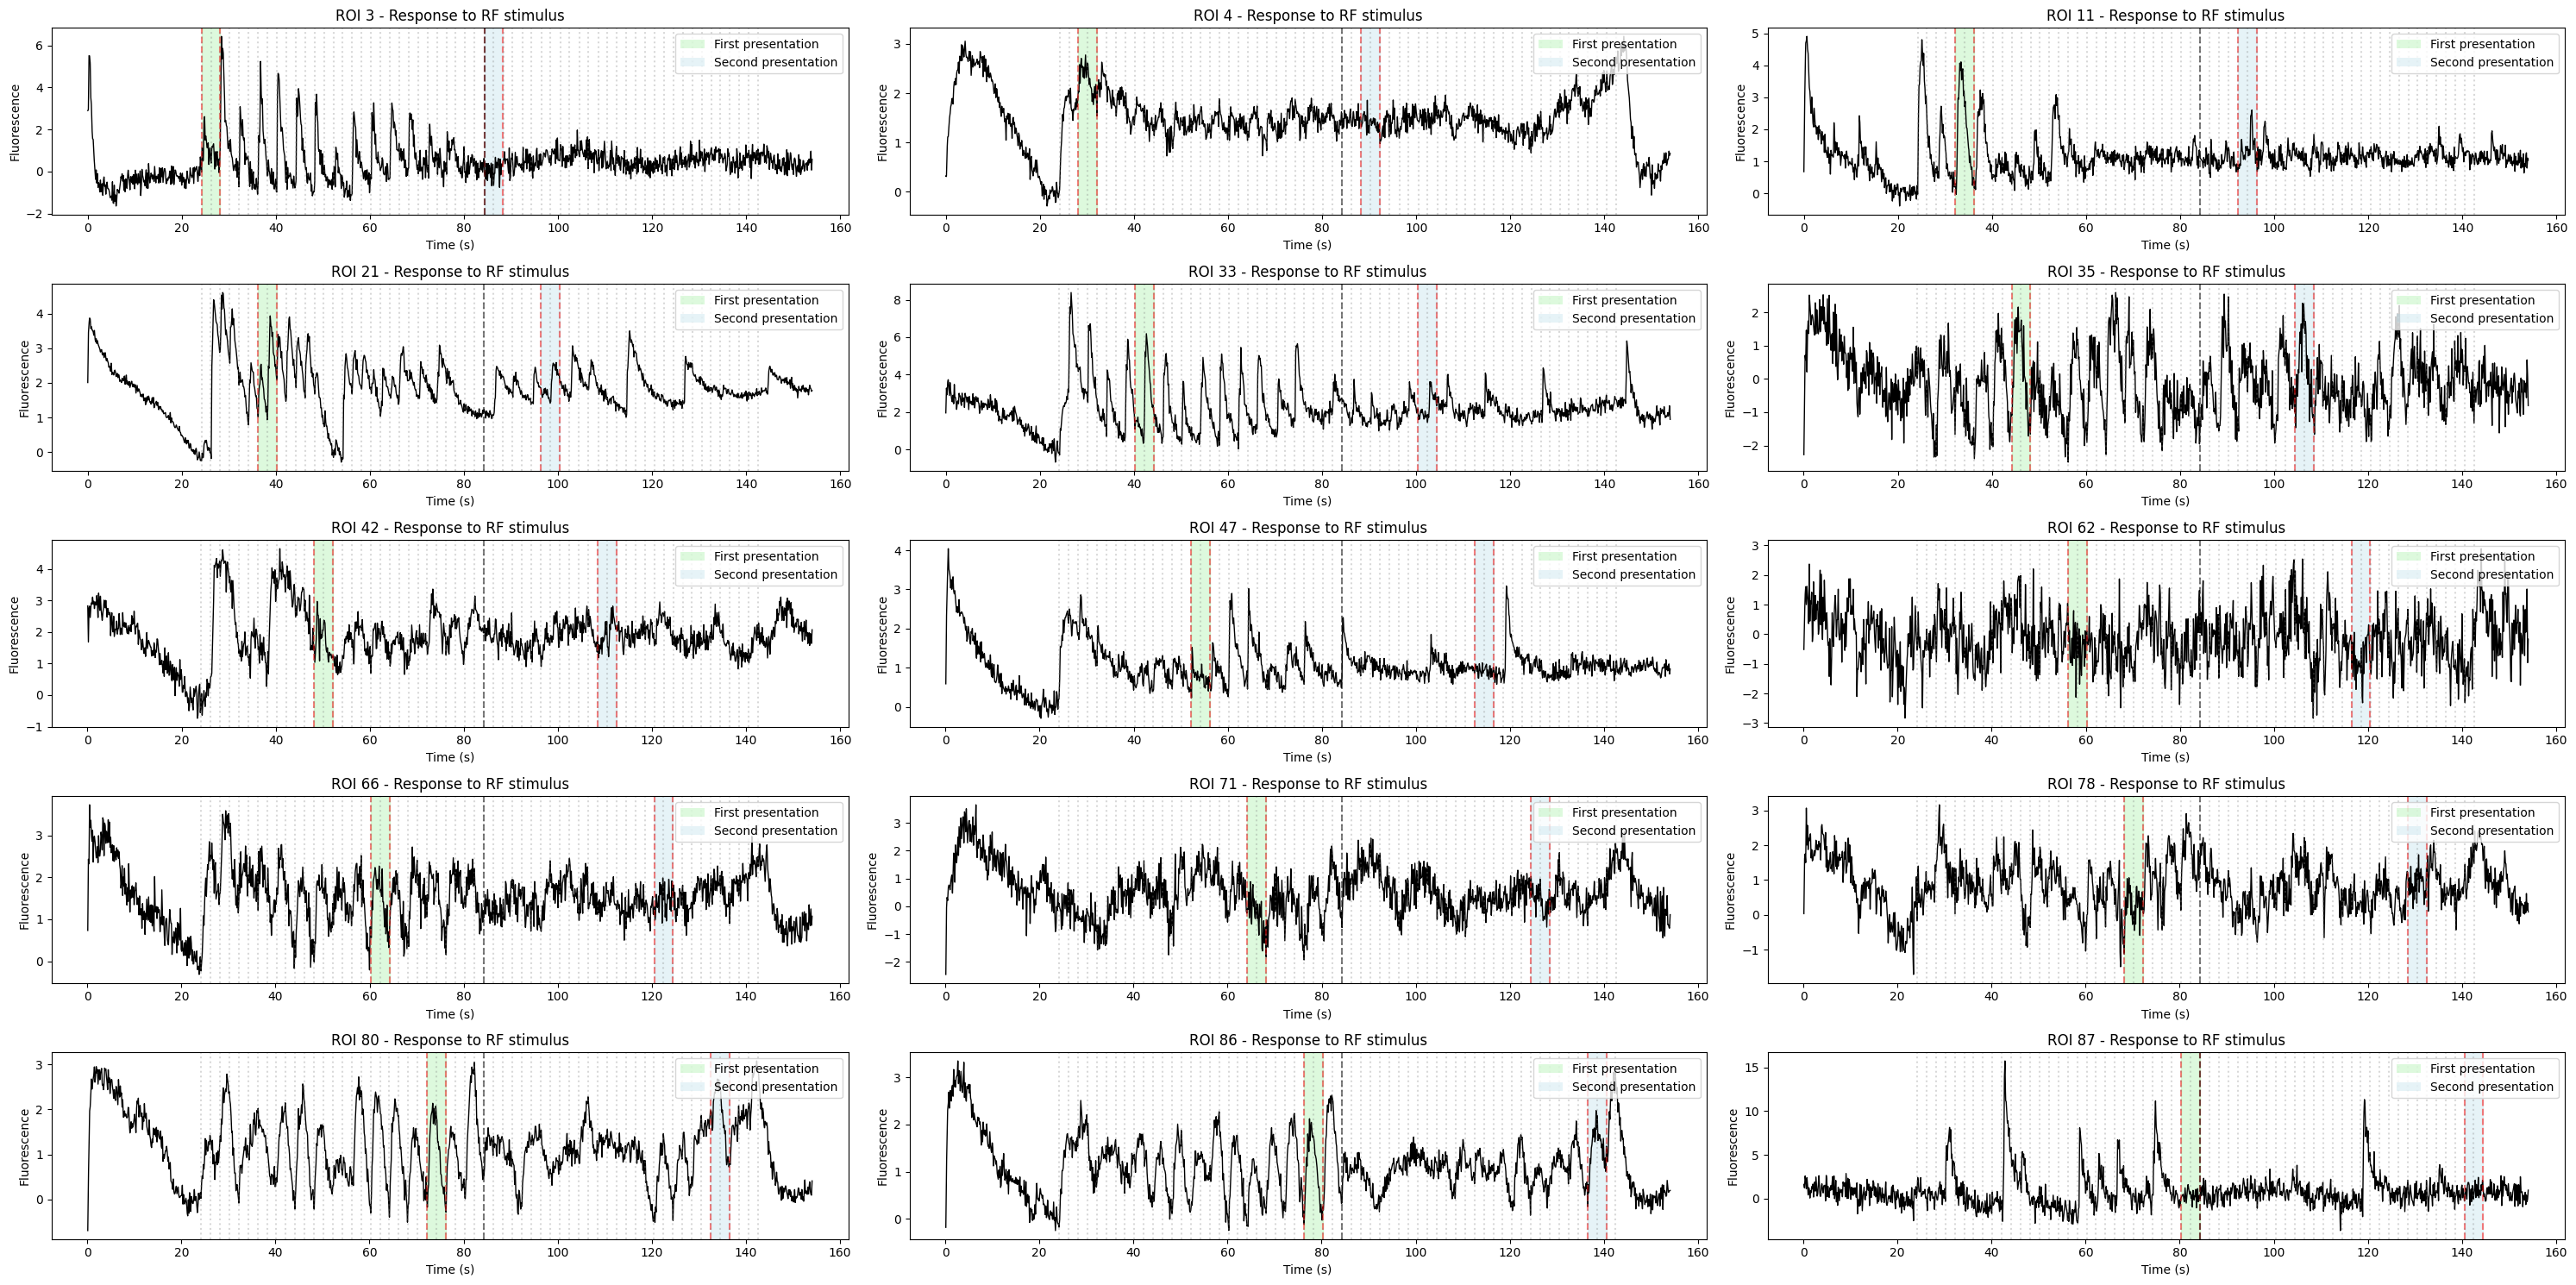

In [235]:
# create one subplot for each roi
fig, axs = plt.subplots(5, 3, figsize=(30, 15))
axs = axs.flatten()  # Flatten the 2D array of axes for easy indexing

for i, roi in enumerate(roi_ids):
    ax = interval_plot_wrapper(PreprocessTraces(), roi, roi_ids, ax=axs[i])
    ax.set_title(f"ROI {roi} - Response to RF stimulus")
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Fluorescence')

plt.tight_layout()
plt.show()


Okay this looks like the location of the stimulus at the preferred location actually had no effect. Lets look at one cell. For roi_id 33 we have nice chirp, nice STA online.  

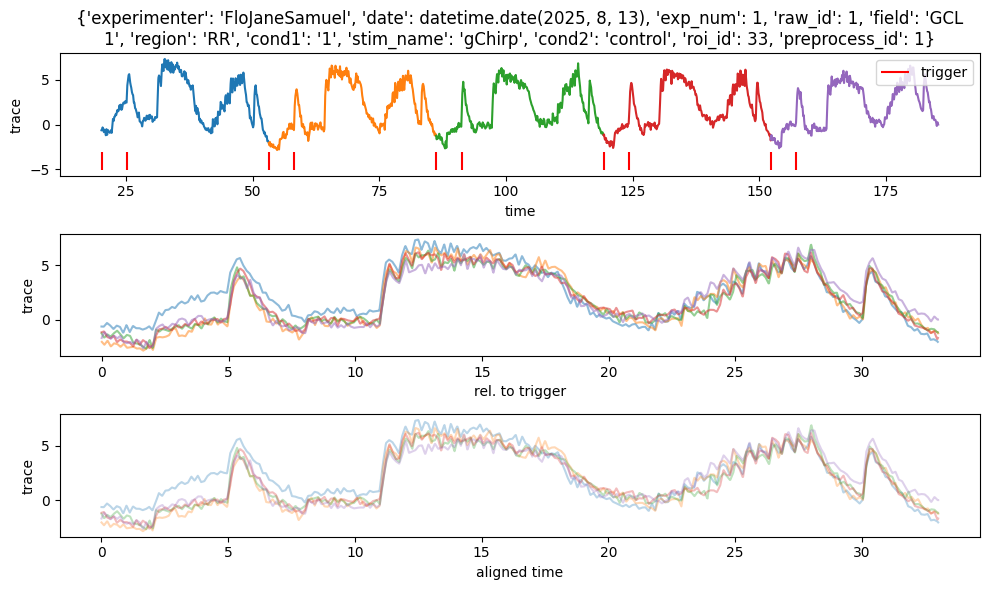

In [214]:
(Snippets() & {"roi_id":33}).plot1()

In [218]:
def plot_roi_mask(roi_id, ax=None):
    mask = (RoiMask().fetch1("roi_mask") == -roi_id) * 100 + (RoiMask().fetch1("roi_mask") >= 1) * 50
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(np.rot90(mask, k=1), cmap="jet")
    ax.set_title(f"ROI {roi_id} Mask")
    ax.axis('off')
    return ax

<Axes: title={'center': 'ROI 33 Mask'}>

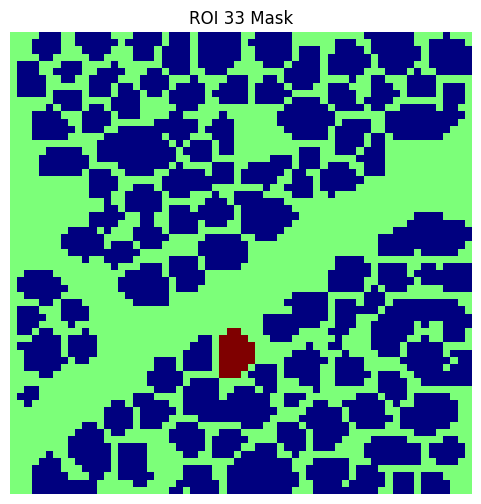

In [219]:
plot_roi_mask(roi_id=33, ax=None)

In [250]:
def get_trace_cutout_for_roi(pp_trace_times, 
                             pp_trace, 
                             triggertimes, 
                             roi_ids, 
                             roi_id):
    """
    Returns the trace cutout for the given ROI id .
    The cutout is defined as the time between the two trigger times for the given ROI index.
    """
    # Get the trigger intervals for this ROI
    trigger_intervals = find_trggertime_for_roi(triggertimes, roi_ids, roi_id)
    [(start_time1, stop_time1),(start_time2,stop_time2)] = trigger_intervals


    # get the traces in that time interval 1 and then 2
    cutout1 = pp_trace[(pp_trace_times >= start_time1) & (pp_trace_times <= stop_time1)]
    cutout2 = pp_trace[(pp_trace_times >= start_time2) & (pp_trace_times <= stop_time2)]

    return cutout1, cutout2

def get_stimulus_location_diiff_to_roi(roi_id, roi_ids, location_list):
    """
    """
    idx = roi_ids.index(roi_id)
    location = location_list[idx]

    loc_diff = [(x - location[0], y - location[1]) for x, y in location_list]
    return loc_diff

def get_sorted_cutrous_for_roi(preprocess_table, roi_id, roi_ids, location_list,ax=None, ):

    # restrict table 
    restricted_pp_table = preprocess_table & {"roi_id": roi_id, "stim_name": "RF"}

    # fetch the trace and trigger times
    pp_trace_times, pp_trace, triggertimes = fetch_pp_trace_triggers(restricted_pp_table)
    
    # get the coutouts for all rois
    all_cutout1s = []
    all_cutout2s = [] 
    for roi in roi_ids:
        cutout1,cutout2 = get_trace_cutout_for_roi(pp_trace_times, 
                             pp_trace, 
                             triggertimes, 
                             roi_ids, 
                             roi)
        all_cutout1s.append(cutout1)
        all_cutout2s.append(cutout2)
    
    # get the distances 
    all_loc_diffs = get_stimulus_location_diiff_to_roi(roi_id, roi_ids, location_list)

    loc_based_ordering = np.argsort([np.linalg.norm(diff) for diff in all_loc_diffs])

    loc_based_cutout1s = [all_cutout1s[i] for i in loc_based_ordering]
    loc_based_cutout2s = [all_cutout2s[i] for i in loc_based_ordering]

    locs = [location_list[i] for i in loc_based_ordering]

    dists = [np.linalg.norm(all_loc_diffs[i]) for i in loc_based_ordering]

    return loc_based_cutout1s, loc_based_cutout2s, locs, dists, pp_trace_times, triggertimes, restricted_pp_table

def plot_loc_based_cutouts(loc_based_cutouts,locs,dists):
    """
    Plots the location based cutouts in one plot with the distance and location as text below the cutout.
    """
    fig, axs = plt.subplots(len(loc_based_cutouts), 1, figsize=(10, 2 * len(loc_based_cutouts)))
    if len(loc_based_cutouts) == 1:
        axs = [axs]  # Ensure axs is always a list for consistency

    abs_max = max([np.max(np.abs(cutout)) for cutout in loc_based_cutouts])
    abs_min = min([np.min(np.abs(cutout)) for cutout in loc_based_cutouts])
    for i, (cutout, loc, dist) in enumerate(zip(loc_based_cutouts, locs, dists)):
        axs[i].plot(cutout)
        axs[i].set_title(f"Cutout {i+1} - Location: {loc}, Distance: {dist:.2f}")
        axs[i].set_xlabel('Time (s)')
        axs[i].set_ylabel('Fluorescence')
        axs[i].grid(True)

        axs[i].set_ylim(abs_min, abs_max)  # Set y-limits to the same range for all plots

    plt.tight_layout()
    plt.show()


        


In [247]:
location_list[roi_ids.index(33)]  # Example to get the location for ROI 33

(20.0, 0.0)

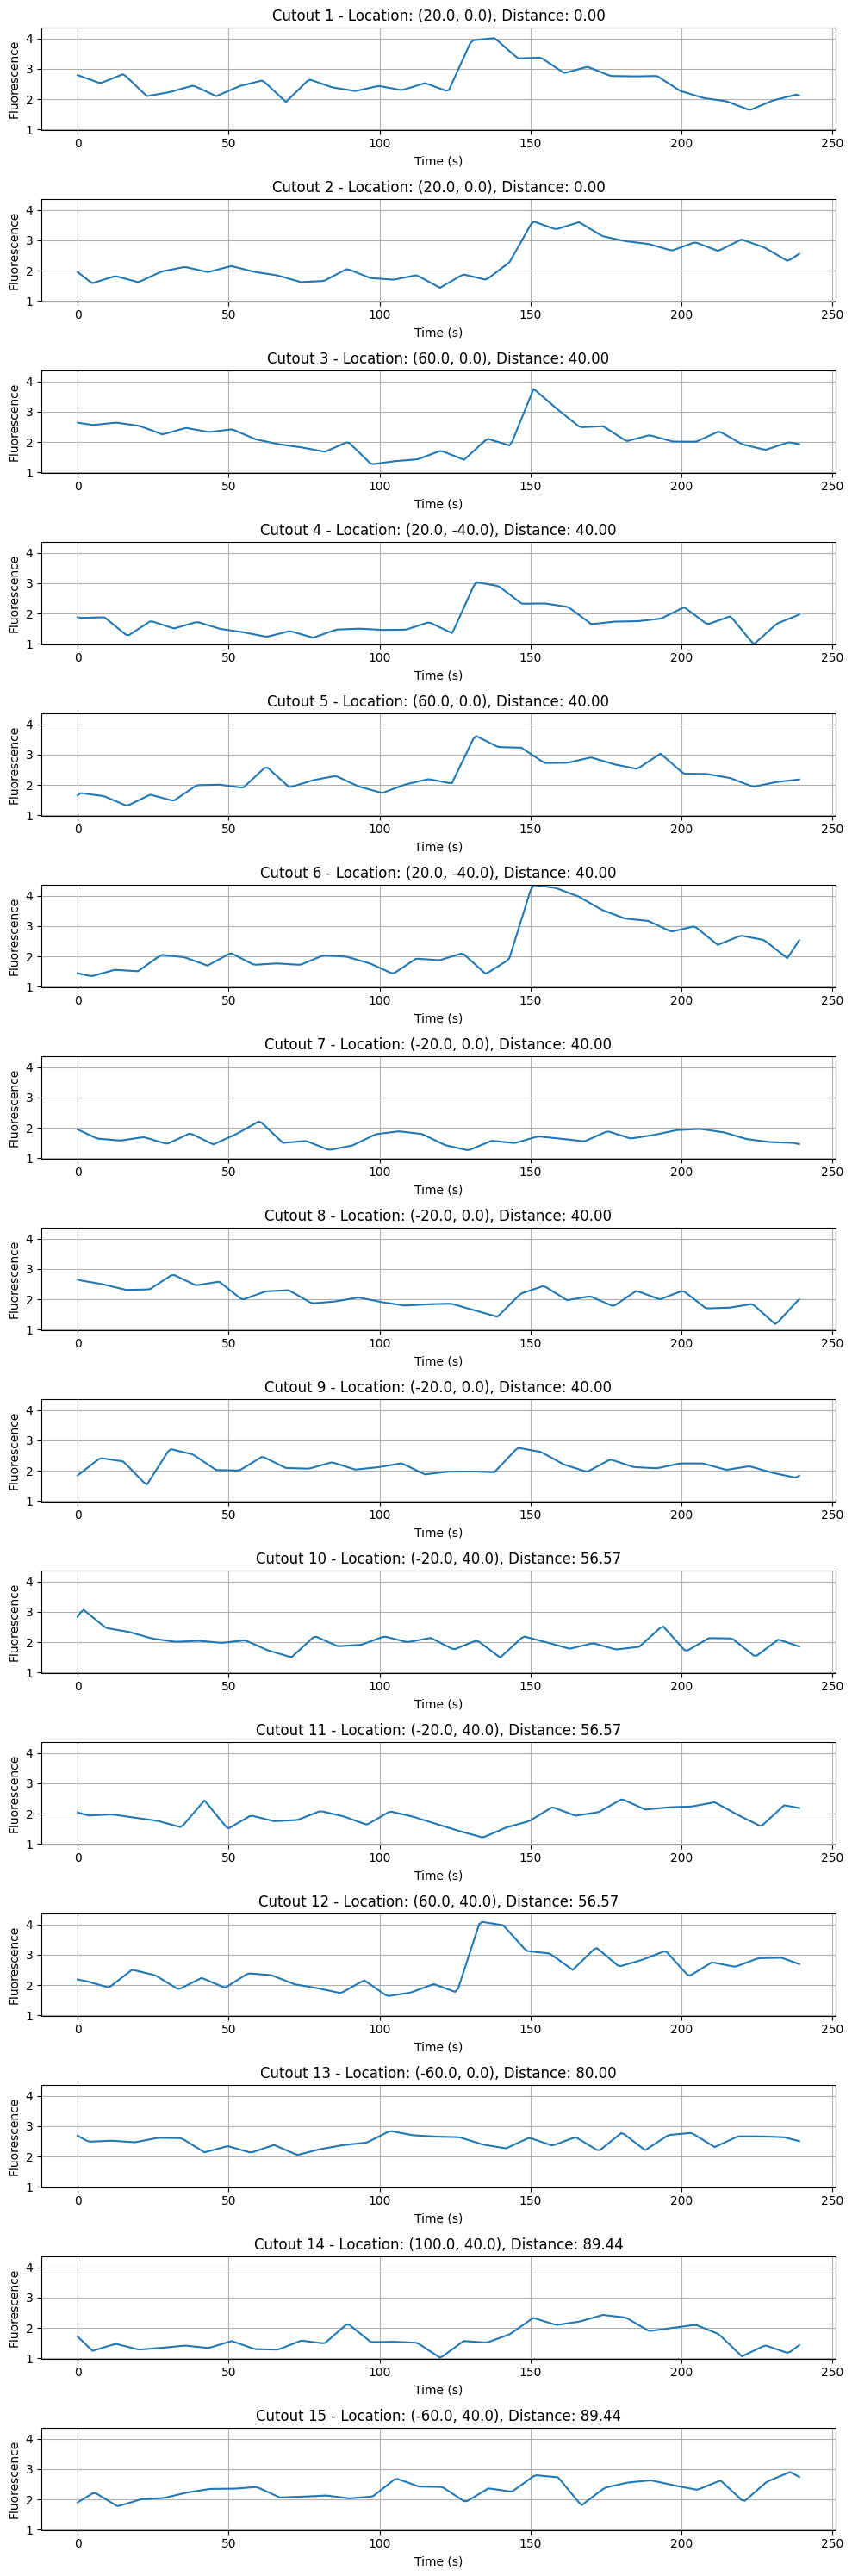

In [251]:
loc_based_cutout1s, loc_based_cutout2s, locs, dists, pp_trace_times, triggertimes, restricted_pp_table = get_sorted_cutrous_for_roi(
    PreprocessTraces(), 
    roi_id=33,
    roi_ids=roi_ids, 
    location_list=location_list,
    ax=None
)

plot_loc_based_cutouts(loc_based_cutout2s, locs, dists)

In [ ]:
# we are plotting the same highlighted plot as before but now all intervals are highlightes with alpha being  the distance